In [1]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

In [2]:
df=pd.read_csv('data/raw/rees46_customer_model.csv')
df.head()

,row_id,user_id,length_mean,start_year_mean,start_yearday_mean,start_month_mean,start_monthday_mean,start_week_mean,start_weekday_mean,start_isweekend_mean,start_hour_mean,haspurchase_mean,click_count_mean,view_count_mean,cart_count_mean,purchase_count_mean,time_to_click_mean,time_to_view_mean,time_to_cart_mean,time_to_purchase_mean,view_revenue_mean,cart_revenue_mean,purchase_revenue_mean,time_to_click_revenue_mean,time_to_view_revenue_mean,time_to_cart_revenue_mean,time_to_purchase_revenue_mean,session_number_mean,inter_session_time_mean,session_recency_mean,purchase_number_mean,inter_purchase_time_mean,purchase_recency_mean,length_sum,start_year_sum,start_yearday_sum,start_month_sum,start_monthday_sum,start_week_sum,start_weekday_sum,start_isweekend_sum,start_hour_sum,haspurchase_sum,click_count_sum,view_count_sum,cart_count_sum,purchase_count_sum,time_to_click_sum,time_to_view_sum,time_to_cart_sum,time_to_purchase_sum,view_revenue_sum,cart_revenue_sum,purchase_revenue_sum,time_to_click_revenue_sum,time_to_view_revenue_sum,time_to_cart_revenue_sum,time_to_purchase_revenue_sum,session_number_sum,inter_session_time_sum,session_recency_sum,purchase_number_sum,inter_purchase_time_sum,purchase_recency_sum,length_min,start_year_min,start_yearday_min,start_month_min,start_monthday_min,start_week_min,start_weekday_min,start_isweekend_min,start_hour_min,haspurchase_min,click_count_min,view_count_min,cart_count_min,purchase_count_min,time_to_click_min,time_to_view_min,time_to_cart_min,time_to_purchase_min,view_revenue_min,cart_revenue_min,purchase_revenue_min,time_to_click_revenue_min,time_to_view_revenue_min,time_to_cart_revenue_min,time_to_purchase_revenue_min,session_number_min,inter_session_time_min,session_recency_min,purchase_number_min,inter_purchase_time_min,purchase_recency_min,length_max,start_year_max,start_yearday_max,start_month_max,start_monthday_max,start_week_max,start_weekday_max,start_isweekend_max,start_hour_max,haspurchase_max,click_count_max,view_count_max,cart_count_max,purchase_count_max,time_to_click_max,time_to_view_max,time_to_cart_max,time_to_purchase_max,view_revenue_max,cart_revenue_max,purchase_revenue_max,time_to_click_revenue_max,time_to_view_revenue_max,time_to_cart_revenue_max,time_to_purchase_revenue_max,session_number_max,inter_session_time_max,session_recency_max,purchase_number_max,inter_purchase_time_max,purchase_recency_max,length_stddev,start_year_stddev,start_yearday_stddev,start_month_stddev,start_monthday_stddev,start_week_stddev,start_weekday_stddev,start_isweekend_stddev,start_hour_stddev,haspurchase_stddev,click_count_stddev,view_count_stddev,cart_count_stddev,purchase_count_stddev,time_to_click_stddev,time_to_view_stddev,time_to_cart_stddev,time_to_purchase_stddev,view_revenue_stddev,cart_revenue_stddev,purchase_revenue_stddev,time_to_click_revenue_stddev,time_to_view_revenue_stddev,time_to_cart_revenue_stddev,time_to_purchase_revenue_stddev,session_number_stddev,inter_session_time_stddev,session_recency_stddev,purchase_number_stddev,inter_purchase_time_stddev,purchase_recency_stddev,length_cv,start_year_cv,start_yearday_cv,start_month_cv,start_monthday_cv,start_week_cv,start_weekday_cv,start_isweekend_cv,start_hour_cv,haspurchase_cv,click_count_cv,view_count_cv,cart_count_cv,purchase_count_cv,time_to_click_cv,time_to_view_cv,time_to_cart_cv,time_to_purchase_cv,view_revenue_cv,cart_revenue_cv,purchase_revenue_cv,time_to_click_revenue_cv,time_to_view_revenue_cv,time_to_cart_revenue_cv,time_to_purchase_revenue_cv,session_number_cv,inter_session_time_cv,session_recency_cv,purchase_number_cv,inter_purchase_time_cv,purchase_recency_cv,session_count_ratio,click_count_ratio,transaction_count_ratio,session_count_month_lag0,session_count_month_lag1,session_count_month_lag2,session_count_month_lag3,session_count_month_ma3,purchase_count_month_lag0,purchase_count_month_lag1,purchase_count_month_lag2,purchase_count_month_lag3,purchase_count_month_ma3,purchase_revenue_month_lag0,purchase_revenue_mon

In [3]:
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 112610
Columns: 276


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112610 entries, 0 to 112609
Columns: 276 entries, row_id to target_actual_profit
dtypes: float64(219), int64(57)
memory usage: 237.1 MB


## Observation:
### Dataset contains 276 columns.
### All features are numerical.

In [5]:
df.dtypes.value_counts()

float64    219
int64       57
Name: count, dtype: int64

In [6]:
df.isnull().sum().sum()

np.int64(0)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['target_event'].value_counts() 

target_event
0    76480
1    36130
Name: count, dtype: int64

In [9]:
round(df['target_event'].value_counts(normalize=True) * 100,2)

target_event
0    67.92
1    32.08
Name: proportion, dtype: float64

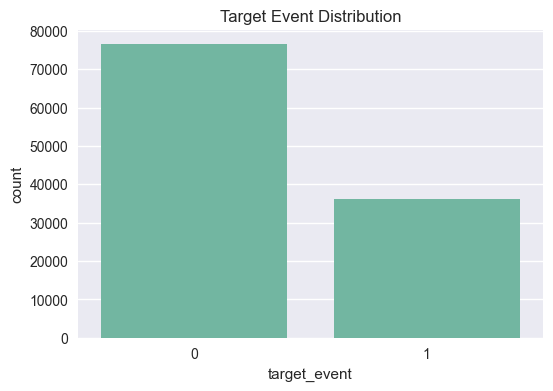

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette('Set2')

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='target_event'
)
plt.title('Target Event Distribution')
plt.show()

In [11]:
df.columns.tolist()

['row_id',
 'user_id',
 'length_mean',
 'start_year_mean',
 'start_yearday_mean',
 'start_month_mean',
 'start_monthday_mean',
 'start_week_mean',
 'start_weekday_mean',
 'start_isweekend_mean',
 'start_hour_mean',
 'haspurchase_mean',
 'click_count_mean',
 'view_count_mean',
 'cart_count_mean',
 'purchase_count_mean',
 'time_to_click_mean',
 'time_to_view_mean',
 'time_to_cart_mean',
 'time_to_purchase_mean',
 'view_revenue_mean',
 'cart_revenue_mean',
 'purchase_revenue_mean',
 'time_to_click_revenue_mean',
 'time_to_view_revenue_mean',
 'time_to_cart_revenue_mean',
 'time_to_purchase_revenue_mean',
 'session_number_mean',
 'inter_session_time_mean',
 'session_recency_mean',
 'purchase_number_mean',
 'inter_purchase_time_mean',
 'purchase_recency_mean',
 'length_sum',
 'start_year_sum',
 'start_yearday_sum',
 'start_month_sum',
 'start_monthday_sum',
 'start_week_sum',
 'start_weekday_sum',
 'start_isweekend_sum',
 'start_hour_sum',
 'haspurchase_sum',
 'click_count_sum',
 'view_coun

In [12]:
identifier_cols = [
    'row_id',
    'user_id'
]
df[identifier_cols].head()

,row_id,user_id
0,31,522576412
1,53,551695186
2,65,561472000
3,85,585643355
4,133,520792937


### row_id and user_id are unique identifiers.
### These columns do not contribute to customer behavior prediction.

In [13]:
df[identifier_cols].nunique()

row_id     112610
user_id     21605
dtype: int64

In [14]:
leakage_cols = [
    'target_revenue',
    'target_customer_value',
    'target_actual_profit'
]
df[leakage_cols].head()

,target_revenue,target_customer_value,target_actual_profit
0,3403.83,171.760358,-13.279611
1,0.00,387.102758,3.592337
2,0.00,347.097991,3.216008
3,937.86,279.270244,-13.185855
4,0.00,91.360471,0.732248


### These columns contain future information.
### Using them would introduce data leakage.

In [15]:
cols_to_drop = [
    'row_id',
    'user_id',
    'target_revenue',
    'target_customer_value',
    'target_actual_profit'
]
df = df.drop(columns=cols_to_drop)

In [16]:
df.shape

(112610, 271)

In [17]:
df.to_csv('data/processed/cleaned_data.csv',index=False)